# Player Behavior Analytics from Poker Event Logs

This notebook presents a modular poker analytics pipeline built from raw PokerNow hand history logs.  
The core parsing, cleaning, and metric logic lives in `src/`, while this notebook focuses on loading the processed tables, generating player-level summaries, and visualizing play styles.

## 1. Load and Normalize Raw Logs

In [1]:
import sys
import matplotlib.pyplot as plt

sys.path.append("..")

from src.data import (
    load_json_files,
    build_hands_df,
    build_players_df,
    build_hand_players_df,
    build_actions_df,
    standardize_player_names
)
from src.metrics import build_player_summary

In [2]:
all_hands = load_json_files("../data/raw")

hands_df = build_hands_df(all_hands)
players_df = build_players_df(all_hands)
hand_players_df = build_hand_players_df(all_hands)
actions_df = build_actions_df(all_hands)

players_df = standardize_player_names(players_df)
hand_players_df = standardize_player_names(hand_players_df)
actions_df = standardize_player_names(actions_df)

player_summary_df = build_player_summary(actions_df, hand_players_df)

## 2. Build the Player Summary Table

Table with all metrics included

In [3]:
player_summary_df.head()

,player_name,hands_played,vpip,preflop_raise_rate,aggression_factor,wtsd_percent,showdown_win_rate,cbet_rate
11,mak,3165,0.347867,0.161453,1.236534,0.134112,0.706638,0.505415
2,bink,3154,0.266646,0.131579,0.831897,0.127100,0.639456,0.477733
21,willy,1827,0.258347,0.155446,1.503268,0.087028,0.754098,0.630573
3,brian,1769,0.482759,0.257773,1.525568,0.199548,0.646853,0.628975
7,jason,1488,0.241263,0.100806,0.850829,0.098790,0.778846,0.595506


In [8]:
player_summary_df[
    player_summary_df["hands_played"] > 500
][["player_name", "hands_played"]].sort_values(
    "hands_played", ascending=False
)

,player_name,hands_played
11,mak,3165
2,bink,3154
21,willy,1827
3,brian,1769
7,jason,1488
4,ethan,1433
18,shiv,1189
15,neech,868
10,kevy,748
17,rohan,639


## 3. Main Visualization: VPIP vs PFR Player Style Map

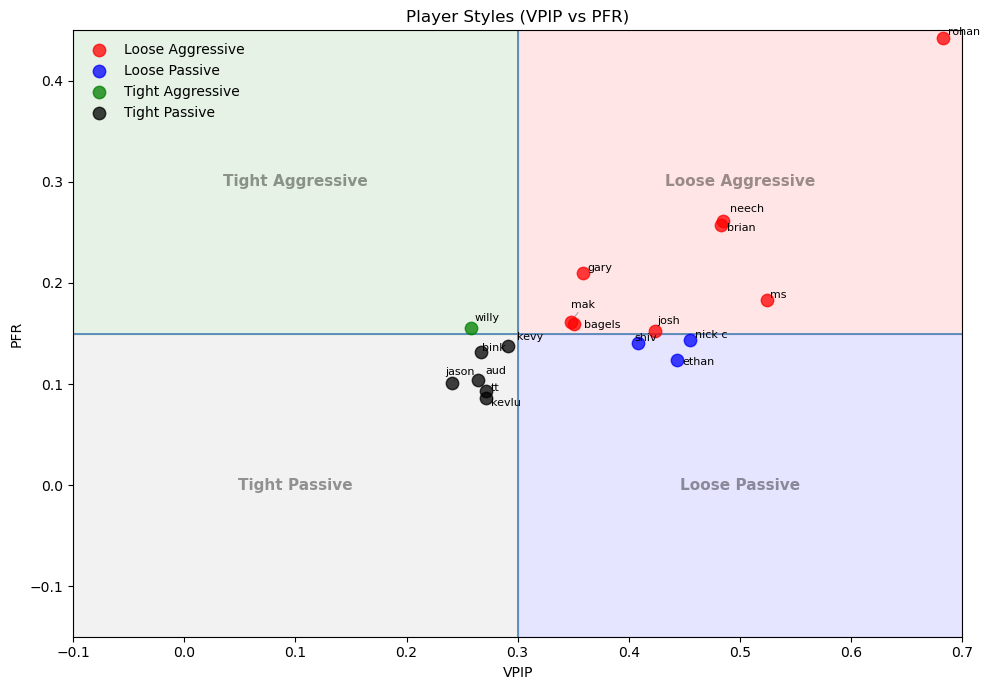

In [9]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

plot_df = player_summary_df.dropna(subset=["vpip", "preflop_raise_rate"]).copy()
plot_df = plot_df[plot_df["hands_played"] >= 100].copy()

vpip_cutoff = 0.30
pfr_cutoff = 0.15

def classify_player(row):
    if row["vpip"] >= vpip_cutoff and row["preflop_raise_rate"] >= pfr_cutoff:
        return "Loose Aggressive"
    elif row["vpip"] >= vpip_cutoff and row["preflop_raise_rate"] < pfr_cutoff:
        return "Loose Passive"
    elif row["vpip"] < vpip_cutoff and row["preflop_raise_rate"] >= pfr_cutoff:
        return "Tight Aggressive"
    else:
        return "Tight Passive"

plot_df["play_style"] = plot_df.apply(classify_player, axis=1)

colors = {
    "Loose Aggressive": "red",
    "Loose Passive": "blue",
    "Tight Aggressive": "green",
    "Tight Passive": "black"
}

x_min, x_max = -0.1, 0.70
y_min, y_max = -0.15, 0.45

fig, ax = plt.subplots(figsize=(10, 7))

ax.add_patch(plt.Rectangle((x_min, y_min), vpip_cutoff - x_min, pfr_cutoff - y_min,
                           color="gray", alpha=0.10, zorder=0))
ax.add_patch(plt.Rectangle((vpip_cutoff, y_min), x_max - vpip_cutoff, pfr_cutoff - y_min,
                           color="blue", alpha=0.10, zorder=0))
ax.add_patch(plt.Rectangle((x_min, pfr_cutoff), vpip_cutoff - x_min, y_max - pfr_cutoff,
                           color="green", alpha=0.10, zorder=0))
ax.add_patch(plt.Rectangle((vpip_cutoff, pfr_cutoff), x_max - vpip_cutoff, y_max - pfr_cutoff,
                           color="red", alpha=0.10, zorder=0))

for style, group in plot_df.groupby("play_style"):
    ax.scatter(
        group["vpip"],
        group["preflop_raise_rate"],
        label=style,
        c=colors[style],
        alpha=0.75,
        s=80,
        zorder=3
    )

texts = []
for _, row in plot_df.iterrows():
    texts.append(
        ax.text(
            row["vpip"],
            row["preflop_raise_rate"],
            row["player_name"],
            fontsize=8,
            zorder=4
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
)

ax.axvline(vpip_cutoff, color="steelblue", linewidth=1.2, zorder=2)
ax.axhline(pfr_cutoff, color="steelblue", linewidth=1.2, zorder=2)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

left_x = (x_min + vpip_cutoff) / 2
right_x = (vpip_cutoff + x_max) / 2
bottom_y = (y_min + pfr_cutoff) / 2
top_y = (pfr_cutoff + y_max) / 2

ax.text(left_x, top_y, "Tight Aggressive", ha="center", va="center",
        fontsize=11, fontweight="bold", alpha=0.4)
ax.text(right_x, top_y, "Loose Aggressive", ha="center", va="center",
        fontsize=11, fontweight="bold", alpha=0.4)
ax.text(left_x, bottom_y, "Tight Passive", ha="center", va="center",
        fontsize=11, fontweight="bold", alpha=0.4)
ax.text(right_x, bottom_y, "Loose Passive", ha="center", va="center",
        fontsize=11, fontweight="bold", alpha=0.4)

ax.set_xlabel("VPIP")
ax.set_ylabel("PFR")
ax.set_title("Player Styles (VPIP vs PFR)")
ax.legend(frameon=False)

plt.tight_layout()

plt.savefig("vpip_pfr_plot.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Secondary Visualization: Showdown Win Rate

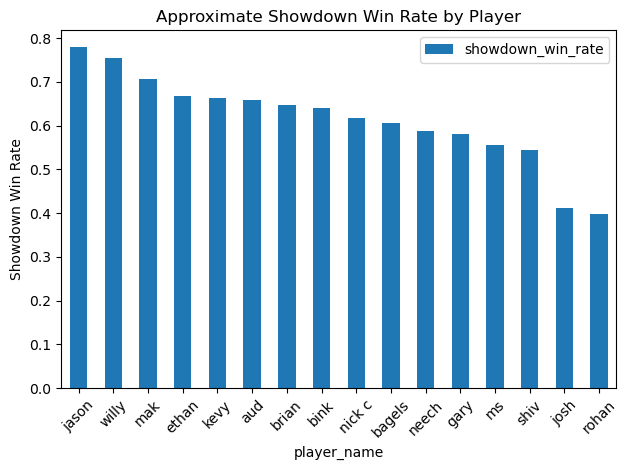

In [6]:
showdown_plot_df = player_summary_df.dropna(subset=["showdown_win_rate"]).sort_values(
    "showdown_win_rate", ascending=False
)

showdown_plot_df.plot(
    x="player_name",
    y="showdown_win_rate",
    kind="bar"
)
plt.xticks(rotation=45)
plt.ylabel("Showdown Win Rate")
plt.title("Approximate Showdown Win Rate by Player")
plt.tight_layout()
plt.show()

## 5. Secondary Visualization: Continuation Bet Rate

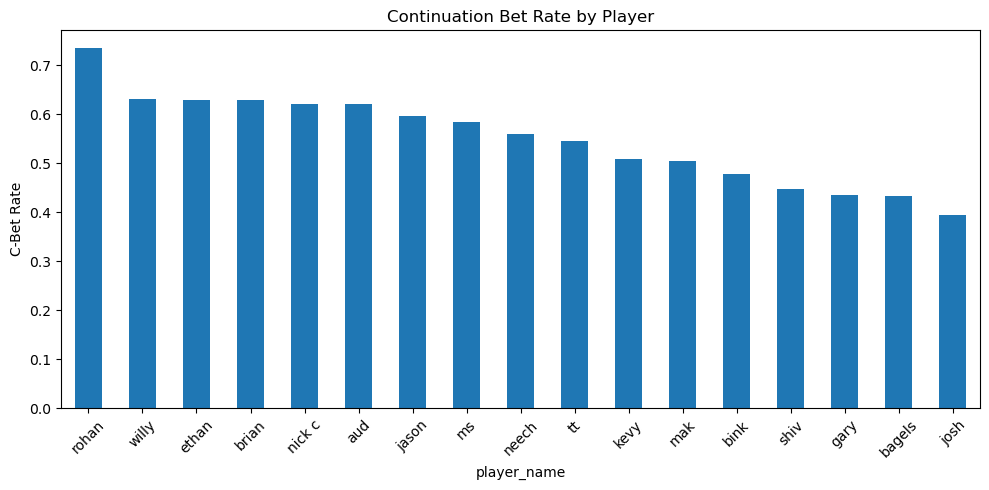

In [7]:
import matplotlib.pyplot as plt

cbet_plot_df = player_summary_df.dropna(subset=["cbet_rate", "hands_played"]).copy()
cbet_plot_df = cbet_plot_df[cbet_plot_df["hands_played"] >= 100]
cbet_plot_df = cbet_plot_df.sort_values("cbet_rate", ascending=False)

cbet_plot_df.plot(
    x="player_name",
    y="cbet_rate",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)

plt.xticks(rotation=45)
plt.ylabel("C-Bet Rate")
plt.title("Continuation Bet Rate by Player")
plt.tight_layout()
plt.show()

## 6. Key Findings

- The VPIP–PFR chart separates players into intuitive strategic archetypes: tight/passive, tight/aggressive, loose/passive, and loose/aggressive.

- **Tight vs Loose** refers to how many hands a player chooses to play:
  - Tight players are more selective and play fewer hands
  - Loose players enter many hands, including weaker ones

- **Aggressive vs Passive** refers to how a player acts once in a hand:
  - Aggressive players bet and raise frequently
  - Passive players tend to call more rather than bet themselves



  
- Several players cluster in the loose-aggressive region, indicating both frequent hand participation and high preflop pressure.

- Rohan stands out as a particularly loose-aggressive player, with both high VPIP and PFR. This suggests he plays many hands and applies consistent pressure. Against this style, a tighter, more selective strategy that traps with strong hands and avoids marginal spots would likely be effective.

- In contrast, players in the loose-passive region tend to call frequently without applying pressure. Against these players, aggressive betting strategies and value-heavy play can be effective, as they are more likely to call than raise.

- Tight-passive players, such as Bink and Jason, participate infrequently and avoid aggressive line. These players can often be exploited by applying pressure in marginal spots, as they are more likely to fold without strong holdings, especially preflop and on rivers.

- Secondary metrics such as showdown win rate add context by showing which players convert deep-hand participation into actual wins, helping distinguish between aggressive but effective play and overly loose strategies.

- Found a ~35 percentage point spread (40%–74%) in postflop follow-through (c-bet rate); players with high preflop aggression but low c-bet rates can be exploited in spots where floating or check-raising the flop is strategically optimal

- Because the dataset comes from PokerNow hand histories from personal games, the analysis is best interpreted as a demonstration of methodology rather than a universal statement about broader poker populations.